### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [ ]:
from utils import * 
from FAPT import * 
from pulse_optimization import *
import sympy as sp

In [3]:
s = Simulation()
tg_list = np.linspace(50.0, 1000.0, 10)
rH = 3
rW = 2
def fitted_pulse_symbolic(t, p):
    tg_sym, wd_sym, amp_sym = p
    return amp_sym, wd_sym

H_base, M_base, M_inv_0_base = prepare_floquet_functions(pulse_shape_builder=fitted_pulse_symbolic, p_names=["tg", "wd", "amp"], s=s, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=False)

In [8]:
import numpy as np
from pulse_optimization import *
from tqdm import tqdm

def make_tg_fixed_floquet_functions(tg_target, cos_wd, cos_amp, H_base, M_base, M_inv_0_base):
    """Fixiert tg und bildet die Optimierungsparameter auf absolute Frequenz und Amplitude ab."""

    def H_func(t, wd_offset, amp_offset):
        return H_base(t, tg_target, cos_wd + wd_offset, cos_amp + amp_offset)

    def M_func(t, wd_offset, amp_offset):
        return M_base(t, tg_target, cos_wd + wd_offset, cos_amp + amp_offset)

    def M_inv_0_func(wd_offset, amp_offset):
        return M_inv_0_base(tg_target, cos_wd + wd_offset, cos_amp + amp_offset)

    return H_func, M_func, M_inv_0_func

def run_single_tg_sequential_optimization(tg_target, s, param_ranges, H_base, M_base, M_inv_0_base, pts_per_ns=40.0, steps_per_ns=20):
    cos_wd, cos_amp = compute_cos_params(s, tg_target)

    d_res = len(s.resonances.keys())

    if d_res != 3:
        raise ValueError(f"Für diese Auswertung wird ein dreidimensionaler Resonanzraum erwartet, erhalten wurde d_res={d_res}.")
    H_func, M_func, M_inv_0_func = make_tg_fixed_floquet_functions(tg_target, cos_wd, cos_amp, H_base, M_base, M_inv_0_base)
    best_p_pop, best_infid_pop = optimize_pulse_parameters(H_func=H_func, M_func=M_func, M_inv_0_func=M_inv_0_func, param_ranges=param_ranges, s=s, tg=tg_target, N_t=100, target_metric="population", verbose=False, popsize=4, maxiter=15, tol=1e-8, polish=True)

    wd_offset_opt = best_p_pop.get("wd_offset", 0.0)
    amp_offset_opt = best_p_pop.get("amp_offset", 0.0)

    wd_val_pop = cos_wd + wd_offset_opt
    Ar_val_pop = cos_amp + amp_offset_opt

    q_sig_pop = lambda t, args=None: Ar_val_pop * np.cos(wd_val_pop * t)

    # ------------------------------------------------------------------
    # SCHRITT 2: Virtual-Z-Winkel aus der Floquet-Rechnung bestimmen
    # ------------------------------------------------------------------

    theta_1, theta_2 = find_virtual_z_angles(best_p_pop, H_func, M_func, M_inv_0_func, tg_target, s, steps_per_ns=steps_per_ns)

    phases = np.zeros(d_res)
    phases[0] = theta_1
    phases[1] = theta_2

    D_Z = np.diag(np.exp(1j * phases))

    # ------------------------------------------------------------------
    # Korrigierte Floquet-Process-Fidelity
    # ------------------------------------------------------------------

    N_steps = max(100, int(np.ceil(tg_target * steps_per_ns)))
    dt = tg_target / float(N_steps)
    t_mids = (np.arange(N_steps) + 0.5) * dt
    p_vals_fixed = tuple(best_p_pop[name] for name in param_ranges)

    _, _, U_floq_proc = compute_pulse_propagator(p_vals_fixed, H_func, M_func, M_inv_0_func, t_mids, dt, tg_target, s)

    U_ideal = np.asarray(s.U_ideal, dtype=complex)
    U_floq_corrected = D_Z @ U_floq_proc

    trace_val_floq = np.trace(U_ideal.conj().T @ U_floq_corrected)
    floq_fid_proc = np.abs(trace_val_floq) ** 2 / d_res**2
    floq_infid_proc = 1.0 - float(np.real(floq_fid_proc))

    # ------------------------------------------------------------------
    # SCHRITT 3: mesolve-Simulation bei unverändertem tg_target
    # ------------------------------------------------------------------

    n_pts_mes = max(101, int(np.ceil(tg_target * pts_per_ns)))
    t_mes = np.linspace(0.0, tg_target, n_pts_mes)

    amp_a_mes = resonant_subspace_column_evolution([s.H0, [s.V1, q_sig_pop]], t_mes, 0, debug=False, s=s)
    amp_b_mes = resonant_subspace_column_evolution([s.H0, [s.V1, q_sig_pop]], t_mes, 1, debug=False, s=s)
    amp_c_mes = resonant_subspace_column_evolution([s.H0, [s.V1, q_sig_pop]], t_mes, 2, debug=False, s=s)

    U_mes_proc = np.zeros((d_res, d_res), dtype=complex)
    U_mes_proc[:, 0] = amp_a_mes[:, -1]
    U_mes_proc[:, 1] = amp_b_mes[:, -1]
    U_mes_proc[:, 2] = amp_c_mes[:, -1]

    # ------------------------------------------------------------------
    # Population-Fidelity aus mesolve
    # ------------------------------------------------------------------

    mes_fid_pop = 0.5 * (np.abs(U_mes_proc[1, 0]) ** 2 + np.abs(U_mes_proc[0, 1]) ** 2)
    mes_infid_pop = 1.0 - float(np.real(mes_fid_pop))

    # ------------------------------------------------------------------
    # SCHRITT 4: Floquet-Virtual-Z-Winkel auf mesolve anwenden
    # ------------------------------------------------------------------

    U_mes_corrected = D_Z @ U_mes_proc

    trace_val_mes = np.trace(U_ideal.conj().T @ U_mes_corrected)
    mes_fid_proc = np.abs(trace_val_mes) ** 2 / d_res**2
    mes_infid_proc = 1.0 - float(np.real(mes_fid_proc))

    return best_infid_pop, mes_infid_pop, floq_infid_proc, mes_infid_proc, theta_1, theta_2, wd_offset_opt, amp_offset_opt


# --- Ausführung der Berechnung ---

param_ranges = {"wd_offset": (-0.001, 0.001), "amp_offset": (-0.05, 0.05)}

sweep_data = {
    "floq_pop": [],
    "mes_pop": [],
    "floq_proc": [],
    "mes_proc": [],
    "theta_1": [],
    "theta_2": [],
    "wd_offset": [],
    "amp_offset": [],
}
for tg in tqdm(tg_list, desc="Virtual-Z Gate-Time Sweep", unit="tg"):
    f_pop, m_pop, f_proc, m_proc, theta_1, theta_2, wd_opt, amp_opt = run_single_tg_sequential_optimization(tg, s, param_ranges, H_base, M_base, M_inv_0_base)
    sweep_data["floq_pop"].append(f_pop)
    sweep_data["mes_pop"].append(m_pop)
    sweep_data["floq_proc"].append(f_proc)
    sweep_data["mes_proc"].append(m_proc)
    sweep_data["theta_1"].append(theta_1)
    sweep_data["theta_2"].append(theta_2)
    sweep_data["wd_offset"].append(wd_opt)
    sweep_data["amp_offset"].append(amp_opt)


Virtual-Z Gate-Time Sweep: 100%|██████████| 10/10 [00:35<00:00,  3.56s/tg]


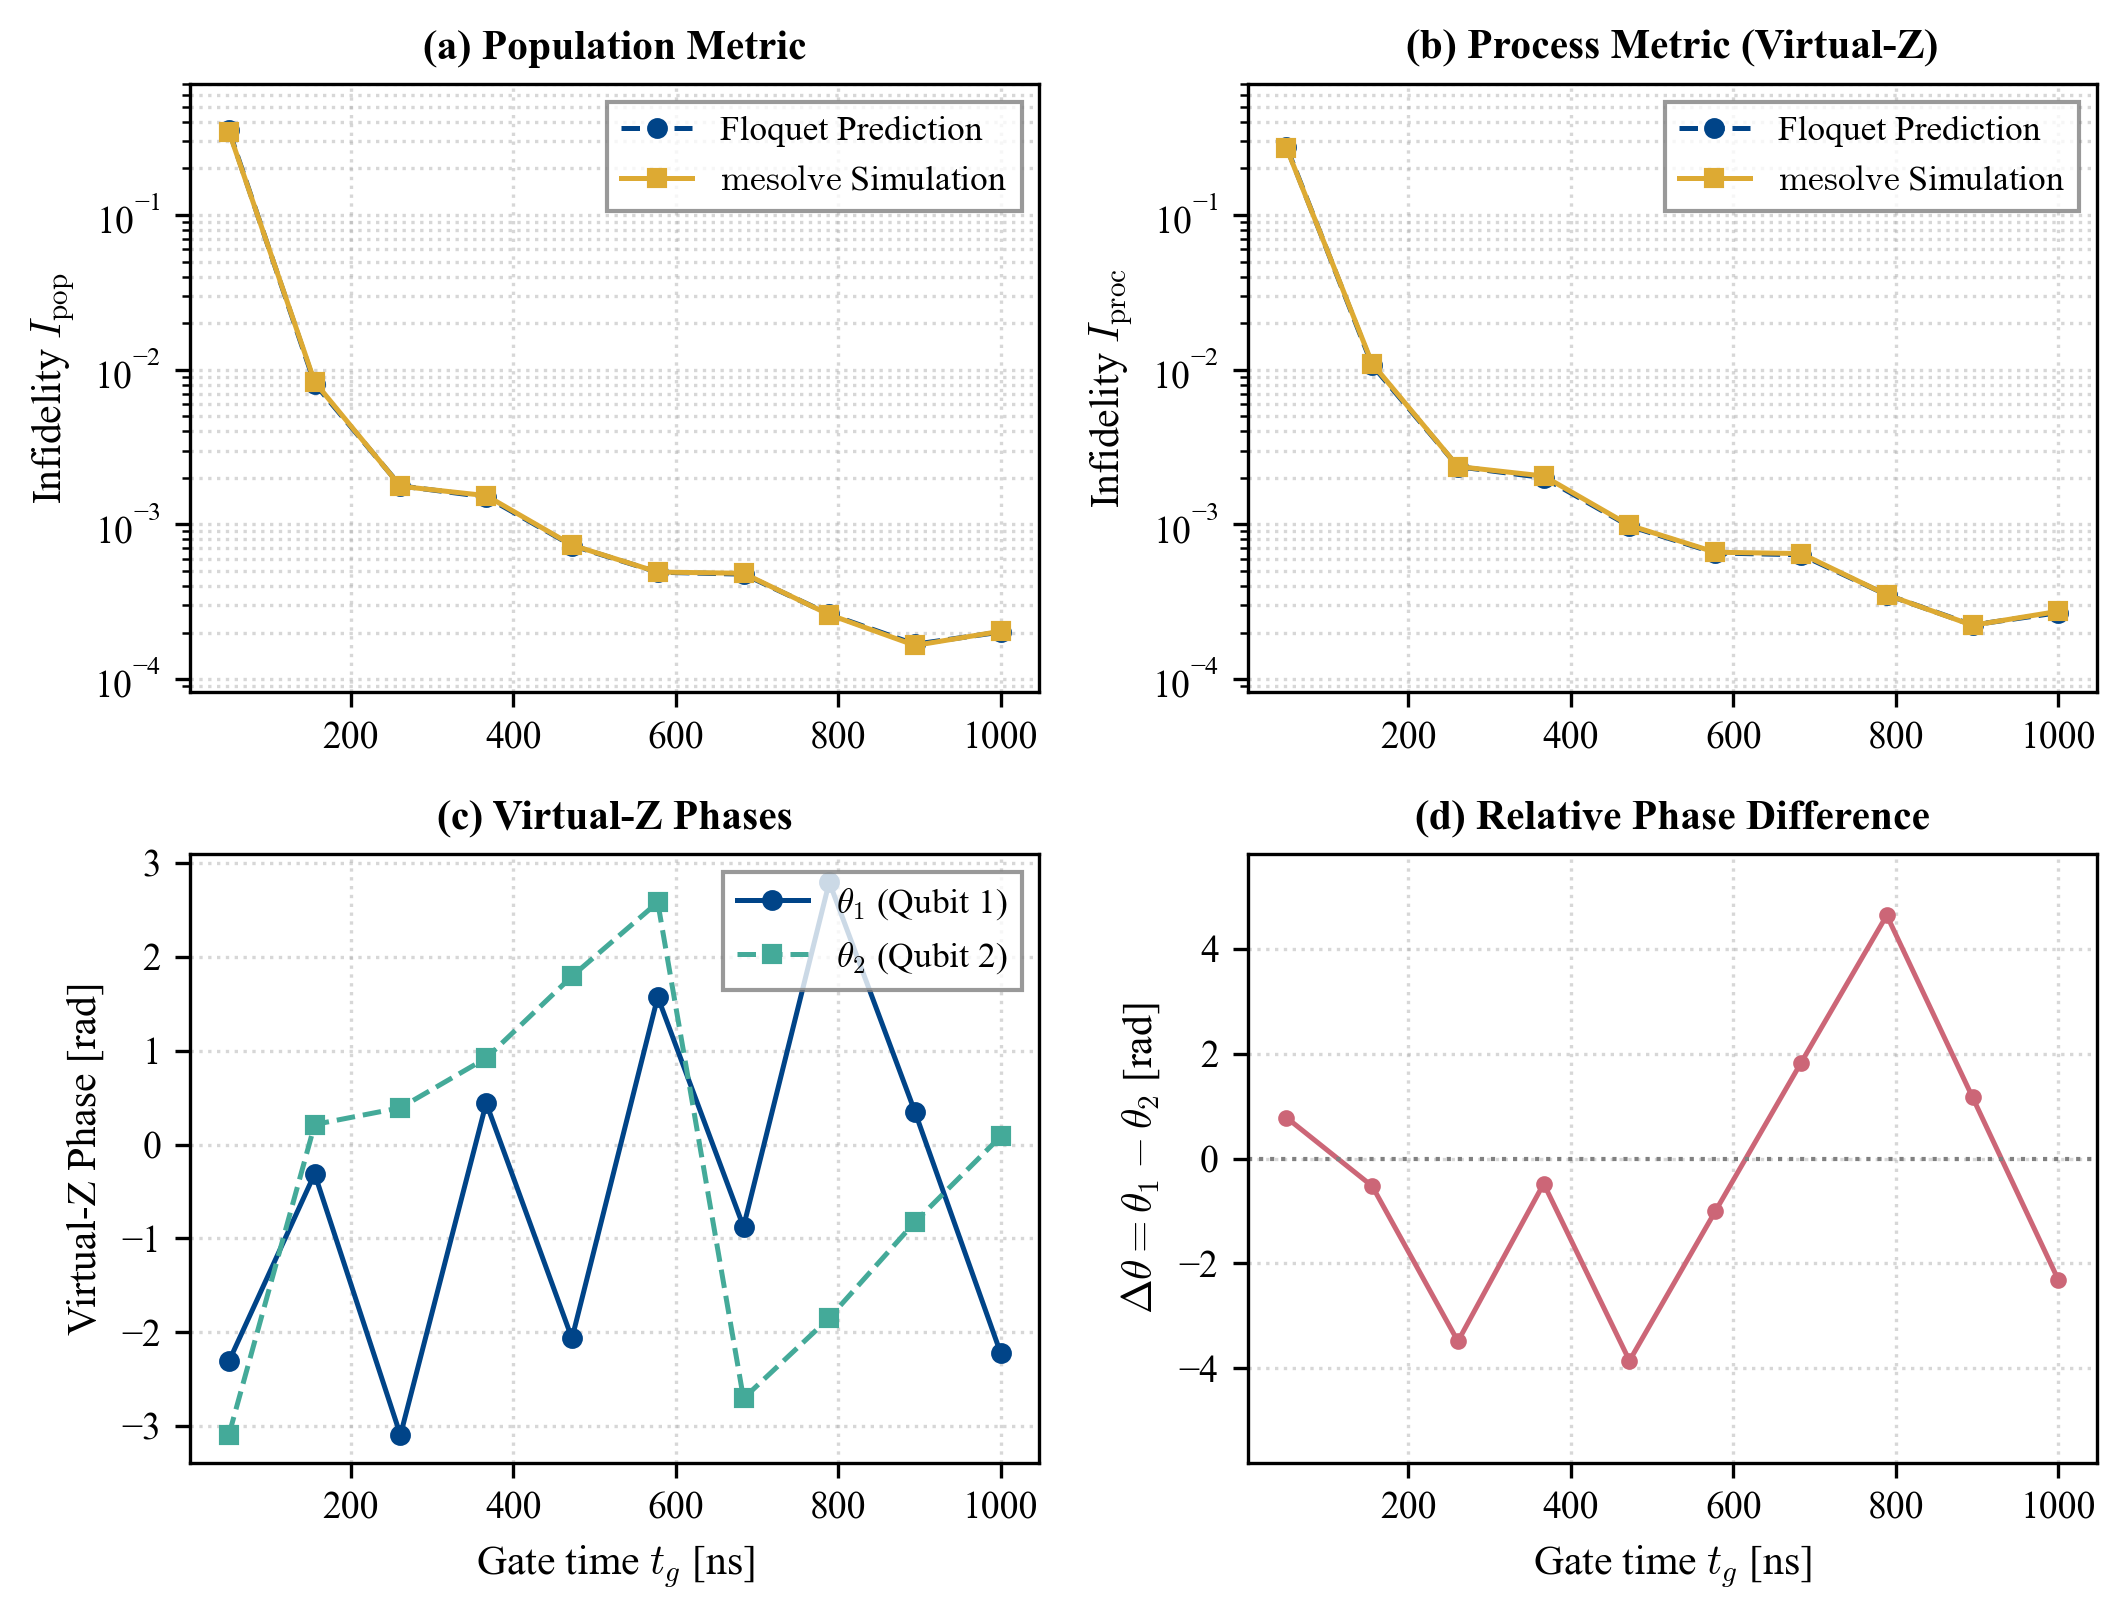

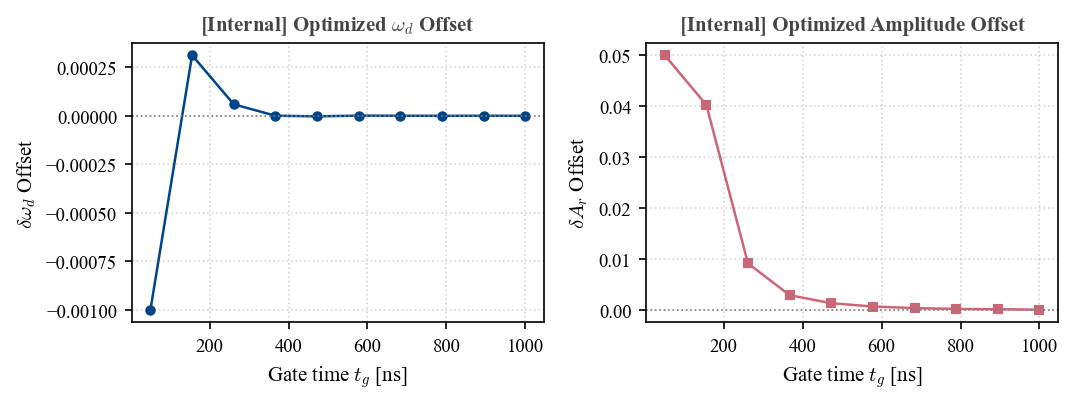

In [9]:
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# 2. Paper-Style Plotting
# ==============================================================================
def setup_paper_style():
    """Richtet Matplotlib-Standards für wissenschaftliche Publikationen ein."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 10,
        "font.size": 10,
        "legend.fontsize": 8.5,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.titlesize": 11,
        "axes.titlesize": 10,
        "lines.linewidth": 1.2,
        "lines.markersize": 4,
    })


def plot_infidelity_sweep(tg_list, results):
    """Erstellt das 2x2 Publication Layout mit Infidelity Plots und Virtual-Z Phasen.

    Wird als PDF für das Paper gespeichert.
    """
    setup_paper_style()

    fig, axs = plt.subplots(2, 2, figsize=(7.2, 5.5), dpi=300)
    (ax1, ax2), (ax3, ax4) = axs

    c_floq, c_mes, c_diff = "#004488", "#DDAA33", "#CC6677"
    c_q1, c_q2 = "#004488", "#44AA99"
    m_floq, m_mes = "o", "s"

    # --- Panel A: Population Infidelity I_pop ---
    ax1.semilogy(
        tg_list,
        results["floq_pop"],
        f"{m_floq}--",
        color=c_floq,
        label=r"Floquet Prediction",
    )
    ax1.semilogy(
        tg_list,
        results["mes_pop"],
        f"{m_mes}-",
        color=c_mes,
        label=r"$\mathrm{mesolve}$ Simulation",
    )
    ax1.set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
    ax1.set_title(r"(a) Population Metric", fontweight="bold")
    ax1.grid(True, which="both", linestyle=":", alpha=0.5)
    ax1.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # --- Panel B: Process Infidelity I_proc ---
    ax2.semilogy(
        tg_list,
        results["floq_proc"],
        f"{m_floq}--",
        color=c_floq,
        label=r"Floquet Prediction",
    )
    ax2.semilogy(
        tg_list,
        results["mes_proc"],
        f"{m_mes}-",
        color=c_mes,
        label=r"$\mathrm{mesolve}$ Simulation",
    )
    ax2.set_ylabel(r"Infidelity $I_{\mathrm{proc}}$")
    ax2.tick_params(labelleft=True)
    ax2.set_title(r"(b) Process Metric (Virtual-Z)", fontweight="bold")
    ax2.grid(True, which="both", linestyle=":", alpha=0.5)
    ax2.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # Y-Achsen von Panel (a) und (b) angleichen für Konsistenz
    y_min = min(
        min(results["floq_pop"]),
        min(results["mes_pop"]),
        min(results["floq_proc"]),
        min(results["mes_proc"]),
    )
    y_max = max(
        max(results["floq_pop"]),
        max(results["mes_pop"]),
        max(results["floq_proc"]),
        max(results["mes_proc"]),
    )
    ax1.set_ylim(y_min * 0.5, y_max * 2.0)
    ax2.set_ylim(y_min * 0.5, y_max * 2.0)

    # --- Panel C: Virtuelle Z-Korrekturwinkel theta_1 & theta_2 ---
    theta_1 = np.array(results["theta_1"])
    theta_2 = np.array(results["theta_2"])

    ax3.plot(
        tg_list,
        theta_1,
        "o-",
        color=c_q1,
        label=r"$\theta_1$ (Qubit 1)",
    )
    ax3.plot(
        tg_list,
        theta_2,
        "s--",
        color=c_q2,
        label=r"$\theta_2$ (Qubit 2)",
    )
    ax3.set_xlabel(r"Gate time $t_g$ [ns]")
    ax3.set_ylabel(r"Virtual-Z Phase [rad]")
    ax3.set_title(r"(c) Virtual-Z Phases", fontweight="bold")
    ax3.grid(True, linestyle=":", alpha=0.5)
    ax3.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # --- Panel D: Phasen-Differenz Delta theta ---
    delta_theta = theta_1 - theta_2

    ax4.plot(tg_list, delta_theta, "o-", color=c_diff, markersize=3)
    ax4.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax4.set_xlabel(r"Gate time $t_g$ [ns]")
    ax4.set_ylabel(r"$\Delta\theta = \theta_1 - \theta_2$ [rad]")
    ax4.tick_params(labelleft=True)
    ax4.set_title(r"(d) Relative Phase Difference", fontweight="bold")
    ax4.grid(True, linestyle=":", alpha=0.5)

    # Dynamic Limits mit Padding
    max_dev = max(abs(np.min(delta_theta)), abs(np.max(delta_theta)))
    if max_dev > 0:
        ax4.set_ylim(-max_dev * 1.25, max_dev * 1.25)

    plt.tight_layout()
    plt.savefig("Figure/infidelity_vs_gate_time_cosdrive.pdf", bbox_inches="tight")
    plt.show()


def plot_internal_parameter_offsets(tg_list, results):
    """Erstellt eine separate Abbildung für die internen Parameter-Offsets.

    Wird NICHT als PDF gespeichert.
    """
    setup_paper_style()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 2.8), dpi=150)

    c_wd, c_amp = "#004488", "#CC6677"

    # Links: Frequency Offset wd
    ax1.plot(tg_list, results["wd_offset"], "o-", color=c_wd)
    ax1.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax1.set_xlabel(r"Gate time $t_g$ [ns]")
    ax1.set_ylabel(r"$\delta\omega_d$ Offset")
    ax1.set_title(
        r"[Internal] Optimized $\omega_d$ Offset",
        fontweight="bold",
        color="#444444",
    )
    ax1.grid(True, linestyle=":", alpha=0.5)

    # Rechts: Amplitude Offset amp
    ax2.plot(tg_list, results["amp_offset"], "s-", color=c_amp)
    ax2.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax2.set_xlabel(r"Gate time $t_g$ [ns]")
    ax2.set_ylabel(r"$\delta A_r$ Offset")
    ax2.set_title(
        r"[Internal] Optimized Amplitude Offset",
        fontweight="bold",
        color="#444444",
    )
    ax2.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


# --- Plots erzeugen ---
plot_infidelity_sweep(tg_list, sweep_data)
plot_internal_parameter_offsets(tg_list, sweep_data)